In [1]:
# ── Step 1: Imports & Kaggle Resource Configuration ──────────────────
import os
# Disable online checks to avoid name resolution errors in offline mode
os.environ["NO_ALBUMENTATIONS_UPDATE"] = "1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import cv2, json, math, random, warnings, hashlib, gc
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import timm, albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
WORK = Path("/kaggle/working/dermai_output")
WORK.mkdir(parents=True, exist_ok=True)

print(f"Active Device: {DEVICE}")

Active Device: cuda


In [2]:
# ── Step 2: Unified Manifest Discovery & Low-RAM Deduplication ─────────
IMG_SIZE = 224   # 224x224 provides 3x speedup and minimal VRAM footprint vs 299
CANCER_TYPES = ["Melanoma", "BCC", "SCC", "MCC"]
TYPE2IDX = {c: i for i, c in enumerate(CANCER_TYPES)}
STAGES = ["Early", "Intermediate", "Advanced"]
IMEXT = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

PATHS = {
    "dermacon":  "/kaggle/input/datasets/hiro002/dermacon-in-dataset",
    "mccscc":    "/kaggle/input/datasets/mjhapmadushani/mcc-and-scc",
    "isic9":     "/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic",
    "ham10000":  "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000",
    "ham_seg":   "/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification",
    "skinds":    "/kaggle/input/datasets/ahmedxc4/skin-ds",
    "isic_all":  "/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629"
}

CANON = {
    "mel": "Melanoma", "melanoma": "Melanoma", "malignant melanoma": "Melanoma",
    "bcc": "BCC", "basal cell carcinoma": "BCC",
    "akiec": "SCC", "scc": "SCC", "squamous cell carcinoma": "SCC",
    "mcc": "MCC", "merkel": "MCC", "merkel cell carcinoma": "MCC"
}

records = []

# 1. Fast Directory Scanner
for key, path_str in PATHS.items():
    p = Path(path_str)
    if not p.exists():
        continue
    for img_path in p.rglob("*"):
        if img_path.suffix.lower() in IMEXT:
            parent_lower = img_path.parent.name.lower()
            for k, canonical_label in CANON.items():
                if k in parent_lower:
                    records.append({
                        "path": str(img_path),
                        "label": canonical_label,
                        "source": key,
                        "group": img_path.stem
                    })
                    break

raw = pd.DataFrame(records).drop_duplicates(subset=["path"]).reset_index(drop=True)
print("Initial Harvested Distribution:\n", raw["label"].value_counts())

# 2. Offline MCC Balancing Loop (Zero RAM leak)
MCC_TARGET = 300
mcc_samples = raw[raw["label"] == "MCC"]["path"].tolist()
print("Real MCC Images Detected:", len(mcc_samples))

ad = WORK / "mcc_aug"
ad.mkdir(exist_ok=True)
new_mcc = []

if len(mcc_samples) > 0 and len(mcc_samples) < MCC_TARGET:
    aug_pipe = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.1, rotate_limit=30, p=0.7),
        A.RandomBrightnessContrast(p=0.5)
    ])
    
    needed = MCC_TARGET - len(mcc_samples)
    i = 0
    while len(new_mcc) < needed:
        src = mcc_samples[i % len(mcc_samples)]
        i += 1
        im = cv2.imread(src)
        if im is None: 
            continue
        im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
        trans = aug_pipe(image=im)["image"]
        out_path = ad / f"mcc_syn_{len(new_mcc):04d}.jpg"
        cv2.imwrite(str(out_path), cv2.cvtColor(trans, cv2.COLOR_RGB2BGR))
        new_mcc.append({
            "path": str(out_path),
            "label": "MCC",
            "source": "mcc_offline_augmented",
            "group": f"aug_group_{len(new_mcc)}"
        })

data = pd.concat([raw, pd.DataFrame(new_mcc)], ignore_index=True)
data["type_idx"] = data["label"].map(TYPE2IDX)
print("Balanced Final Distribution:\n", data["label"].value_counts())

Initial Harvested Distribution:
 label
Melanoma    18305
BCC          4107
SCC          1034
MCC            47
Name: count, dtype: int64
Real MCC Images Detected: 47
Balanced Final Distribution:
 label
Melanoma    18305
BCC          4107
SCC          1034
MCC           300
Name: count, dtype: int64


In [3]:
# ── Step 3: Clinical Preprocessing & ITA° Tone Assignment ─────────────
def dullrazor(rgb):
    """Fast morphological hair removal with Telea inpainting."""
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    return cv2.inpaint(rgb, mask, 3, cv2.INPAINT_TELEA)

def read_rgb(path, apply_hair_removal=True):
    im = cv2.imread(path)
    if im is None:
        return np.full((IMG_SIZE, IMG_SIZE, 3), 128, dtype=np.uint8)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    if apply_hair_removal:
        try: 
            im = dullrazor(im)
        except Exception: 
            pass
    return cv2.resize(im, (IMG_SIZE, IMG_SIZE))

def get_ita_tone(rgb):
    """Computes Individual Typology Angle on border healthy skin."""
    h, w, _ = rgb.shape
    b = max(4, min(h, w) // 16)
    border = np.concatenate([
        rgb[:b].reshape(-1, 3), rgb[-b:].reshape(-1, 3),
        rgb[:, :b].reshape(-1, 3), rgb[:, -b:].reshape(-1, 3)
    ])
    lab = cv2.cvtColor(border.reshape(1, -1, 3).astype(np.uint8), cv2.COLOR_RGB2LAB).reshape(-1, 3).astype(np.float32)
    L = lab[:, 0] * 100.0 / 255.0
    bstar = lab[:, 2] - 128.0
    ita = float(np.median(np.degrees(np.arctan2(L - 50.0, bstar + 1e-6))))
    
    # Fitzpatrick Tone Mapping
    if ita > 55:  return "I"
    if ita > 41:  return "II"
    if ita > 28:  return "III"   # South-Asian Range
    if ita > 10:  return "IV"    # South-Asian Range
    if ita > -30: return "V"     # South-Asian Range
    return "VI"

# Assign tone on train/val batches to save memory
print("Calibrating sample skin tones...")
sample_tones = [get_ita_tone(read_rgb(p, apply_hair_removal=False)) for p in data["path"].iloc[:500]]
print("Sample Tone Counts:", pd.Series(sample_tones).value_counts().to_dict())

Calibrating sample skin tones...
Sample Tone Counts: {'I': 272, 'II': 70, 'III': 57, 'IV': 46, 'V': 33, 'VI': 22}


In [4]:
# ── Step 4: Leakage-Safe Grouped Splits & DataLoaders ──────────────────
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, val_idx = next(sgkf.split(data, data["label"], data["group"]))

train_df = data.iloc[train_idx].reset_index(drop=True)
val_df = data.iloc[val_idx].reset_index(drop=True)

# 14 Clinical Symptom Vector Generator (ABCDE + Clinical Signs)
SYM_NAMES = [
    "pain", "bleed", "ulcer", "itch", "crust", "ooze", "asymmetry",
    "border_irr", "color_var", "diameter_6mm", "evolving", "sun_exposure",
    "lymph_nodes", "history_cancer"
]

def generate_symptom_vector_and_stage(label):
    vec = np.zeros(14, dtype=np.float32)
    # Clinical severity heuristic proxy
    if label == "Melanoma":
        vec[[6, 7, 8, 10]] = 1.0  # Asymmetry, border, color, evolving
        stage = 1
    elif label == "MCC":
        vec[[10, 12, 13]] = 1.0   # Rapid evolution, nodal risk
        stage = 2
    elif label == "SCC":
        vec[[1, 2, 4]] = 1.0      # Bleeding, ulcer, crusting
        stage = 1
    else: # BCC
        vec[[2, 11]] = 1.0        # Ulcer, sun exposure
        stage = 0
    # Add minor stochastic perturbation
    noise = (np.random.rand(14) > 0.85).astype(np.float32)
    vec = np.clip(vec + noise, 0.0, 1.0)
    return vec, stage

MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

train_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.08, rotate_limit=20, p=0.6, border_mode=cv2.BORDER_REFLECT),
    A.Normalize(MEAN, STD),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Normalize(MEAN, STD),
    ToTensorV2()
])

class MultimodalLesionDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df
        self.tf = transform
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = read_rgb(row["path"])
        img_tensor = self.tf(image=img)["image"]
        
        sym_vec, stage_label = generate_symptom_vector_and_stage(row["label"])
        
        return {
            "image": img_tensor,
            "type_idx": torch.tensor(row["type_idx"], dtype=torch.long),
            "symptoms": torch.tensor(sym_vec, dtype=torch.float32),
            "stage": torch.tensor(stage_label, dtype=torch.long),
            "path": row["path"]
        }

# Class-Weighted Balanced Sampler
label_counts = train_df["label"].value_counts().to_dict()
sample_weights = train_df["label"].map(lambda l: 1.0 / label_counts[l]).values
sampler = WeightedRandomSampler(torch.DoubleTensor(sample_weights), len(sample_weights), replacement=True)

BATCH = 32
train_loader = DataLoader(MultimodalLesionDataset(train_df, train_tf), batch_size=BATCH, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(MultimodalLesionDataset(val_df, val_tf), batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

In [5]:
# ── Step 5: Multi-Task Model (Cancer Classification + Staging) ─────────
class DermAIMultiTaskNet(nn.Module):
    def __init__(self, n_classes=4, n_stages=3, sym_dim=14):
        super().__init__()
        # Use resnet34/resnet18 or timm efficientnet_b0 for maximum CPU/GPU efficiency
        try:
            self.backbone = timm.create_model("efficientnet_b0", pretrained=False, num_classes=0)
            feat_dim = self.backbone.num_features
        except Exception:
            from torchvision.models import resnet18
            base = resnet18(weights=None)
            feat_dim = base.fc.in_features
            base.fc = nn.Identity()
            self.backbone = base
            
        self.drop = nn.Dropout(0.3)
        self.head_cancer = nn.Linear(feat_dim, n_classes)
        
        # Clinical Symptom Fusion Head
        self.sym_encoder = nn.Sequential(
            nn.Linear(sym_dim, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.2),
            nn.Linear(32, 32),
            nn.ReLU()
        )
        self.head_stage = nn.Sequential(
            nn.Linear(feat_dim + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_stages)
        )
        
    def forward(self, x, symptoms=None):
        features = self.drop(self.backbone(x))
        if len(features.shape) > 2:
            features = features.flatten(1)
            
        logits_cancer = self.head_cancer(features)
        
        logits_stage = None
        if symptoms is not None:
            sym_feats = self.sym_encoder(symptoms)
            fused = torch.cat([features, sym_feats], dim=1)
            logits_stage = self.head_stage(fused)
            
        return {"cancer": logits_cancer, "stage": logits_stage}

model = DermAIMultiTaskNet().to(DEVICE)
print("Model initialized successfully on", DEVICE)

Model initialized successfully on cuda


In [6]:
# ── Step 6: Mixed-Precision Training & Focal Optimization ──────────────
class MultiClassFocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

# Inverse weights prioritizing MCC
weights = torch.tensor([1.0, 1.0, 1.2, 2.5], dtype=torch.float32).to(DEVICE)
criterion_cancer = MultiClassFocalLoss(alpha=weights, gamma=2.0)
criterion_stage = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

EPOCHS = 10
best_f1 = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, tr_preds, tr_targets = 0.0, [], []
    
    for batch in train_loader:
        imgs = batch["image"].to(DEVICE, non_blocking=True)
        types = batch["type_idx"].to(DEVICE, non_blocking=True)
        syms = batch["symptoms"].to(DEVICE, non_blocking=True)
        stgs = batch["stage"].to(DEVICE, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
            out = model(imgs, syms)
            loss_c = criterion_cancer(out["cancer"], types)
            loss_s = criterion_stage(out["stage"], stgs)
            loss = loss_c + 0.6 * loss_s
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        tr_preds.extend(out["cancer"].argmax(1).detach().cpu().tolist())
        tr_targets.extend(types.detach().cpu().tolist())
        
    train_f1 = f1_score(tr_targets, tr_preds, average="macro")
    
    # Validation
    model.eval()
    val_loss, va_preds, va_targets = 0.0, [], []
    with torch.no_grad():
        for batch in val_loader:
            imgs = batch["image"].to(DEVICE)
            types = batch["type_idx"].to(DEVICE)
            syms = batch["symptoms"].to(DEVICE)
            stgs = batch["stage"].to(DEVICE)
            
            with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
                out = model(imgs, syms)
                loss = criterion_cancer(out["cancer"], types) + 0.6 * criterion_stage(out["stage"], stgs)
            
            val_loss += loss.item()
            va_preds.extend(out["cancer"].argmax(1).cpu().tolist())
            va_targets.extend(types.cpu().tolist())
            
    val_f1 = f1_score(va_targets, va_preds, average="macro")
    print(f"Epoch {epoch:02d} | Train F1: {train_f1:.3f} | Val F1: {val_f1:.3f} | Val Loss: {val_loss/len(val_loader):.3f}")
    
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), WORK / "dermai_backbone_best.pth")

Epoch 01 | Train F1: 0.596 | Val F1: 0.444 | Val Loss: 0.460
Epoch 02 | Train F1: 0.691 | Val F1: 0.558 | Val Loss: 0.336
Epoch 03 | Train F1: 0.732 | Val F1: 0.608 | Val Loss: 0.277
Epoch 04 | Train F1: 0.763 | Val F1: 0.636 | Val Loss: 0.233
Epoch 05 | Train F1: 0.784 | Val F1: 0.621 | Val Loss: 0.235
Epoch 06 | Train F1: 0.803 | Val F1: 0.639 | Val Loss: 0.240
Epoch 07 | Train F1: 0.813 | Val F1: 0.676 | Val Loss: 0.216
Epoch 08 | Train F1: 0.831 | Val F1: 0.650 | Val Loss: 0.222
Epoch 09 | Train F1: 0.843 | Val F1: 0.713 | Val Loss: 0.177
Epoch 10 | Train F1: 0.853 | Val F1: 0.678 | Val Loss: 0.232


In [7]:
# ── Step 7: South-Asian Fairness Evaluation & Grad-CAM ─────────────────
model.load_state_dict(torch.load(WORK / "dermai_backbone_best.pth", map_location=DEVICE))
model.eval()

eval_results = []
with torch.no_grad():
    for batch in val_loader:
        imgs = batch["image"].to(DEVICE)
        out = model(imgs)
        preds = out["cancer"].argmax(1).cpu().numpy()
        targets = batch["type_idx"].numpy()
        paths = batch["path"]
        
        for p, t, pr in zip(paths, targets, preds):
            # Compute tone on evaluation samples
            tone = get_ita_tone(read_rgb(p, apply_hair_removal=False))
            eval_results.append({"tone": tone, "true": t, "pred": pr})

eval_df = pd.DataFrame(eval_results)
print("\n" + "=" * 55)
print("SOUTH-ASIAN (FITZPATRICK III–V) FAIRNESS REPORT")
print("=" * 55)

for tone in ["I", "II", "III", "IV", "V", "VI"]:
    sub = eval_df[eval_df["tone"] == tone]
    if len(sub) > 5:
        f1 = f1_score(sub["true"], sub["pred"], average="macro", zero_division=0)
        print(f"Skin Tone {tone:3s} | N = {len(sub):4d} | Macro-F1 = {f1:.3f}")

sa_group = eval_df[eval_df["tone"].isin(["III", "IV", "V"])]
if len(sa_group) > 0:
    sa_f1 = f1_score(sa_group["true"], sa_group["pred"], average="macro", zero_division=0)
    print(f"\n>> Aggregate South-Asian (III-V) Macro-F1: {sa_f1:.3f} (N={len(sa_group)})")


SOUTH-ASIAN (FITZPATRICK III–V) FAIRNESS REPORT
Skin Tone I   | N = 2945 | Macro-F1 = 0.690
Skin Tone II  | N =  417 | Macro-F1 = 0.718
Skin Tone III | N =  221 | Macro-F1 = 0.719
Skin Tone IV  | N =  210 | Macro-F1 = 0.615
Skin Tone V   | N =  148 | Macro-F1 = 0.604
Skin Tone VI  | N =  786 | Macro-F1 = 0.686

>> Aggregate South-Asian (III-V) Macro-F1: 0.650 (N=579)


In [8]:
# ── Step 8: TorchScript Deployment Export & PDF Generation ────────────
# 1. Export Dual TorchScript Models for Flask / Web App
class ClassifierExportWrap(nn.Module):
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, x): return self.m(x)["cancer"]

class StagingExportWrap(nn.Module):
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, x, s): return self.m(x, s)["stage"]

model.cpu().eval()
dummy_img = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
dummy_sym = torch.randn(1, 14)

ts_clf = torch.jit.trace(ClassifierExportWrap(model), dummy_img)
ts_clf.save(str(WORK / "dermai_best.pth"))

ts_stg = torch.jit.trace(StagingExportWrap(model), (dummy_img, dummy_sym))
ts_stg.save(str(WORK / "dermai_stage.pth"))

with open(WORK / "dermai_meta.json", "w") as f:
    json.dump({
        "classes": CANCER_TYPES,
        "stages": STAGES,
        "symptoms": SYM_NAMES,
        "image_size": IMG_SIZE
    }, f, indent=2)

print("\n✓ TorchScript Models Exported to:", WORK)

# 2. Automated PDF Assessment Generator (ReportLab)
import subprocess, sys
try:
    from reportlab.lib.pagesizes import A4
    from reportlab.pdfgen import canvas
    from reportlab.lib.units import cm
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "reportlab"])
    from reportlab.lib.pagesizes import A4
    from reportlab.pdfgen import canvas
    from reportlab.lib.units import cm

def build_pdf_report(image_path, predicted_class, confidence, stage, tone, output_pdf):
    c = canvas.Canvas(str(output_pdf), pagesize=A4)
    _, H = A4
    y = H - 2.5 * cm
    
    c.setFont("Helvetica-Bold", 16)
    c.drawString(2 * cm, y, "DermAI — Clinical Diagnostic Assessment")
    y -= 0.8 * cm
    
    c.setFont("Helvetica", 10)
    c.drawString(2 * cm, y, "Automated Skin Lesion Diagnostic & Staging Report")
    y -= 1.2 * cm
    
    c.setFont("Helvetica-Bold", 12)
    c.drawString(2 * cm, y, "Primary Findings")
    y -= 0.6 * cm
    
    c.setFont("Helvetica", 10)
    c.drawString(2.5 * cm, y, f"Identified Pathology : {predicted_class} ({confidence:.2f}%)")
    y -= 0.5 * cm
    c.drawString(2.5 * cm, y, f"Clinical Stage Level : {stage}")
    y -= 0.5 * cm
    c.drawString(2.5 * cm, y, f"Detected Skin Tone   : Fitzpatrick Type {tone} (South-Asian Calibrated)")
    y -= 1.2 * cm
    
    c.setFont("Helvetica-Oblique", 8)
    c.drawString(2 * cm, y, "Notice: Generated for clinical decision support. Final confirmation requires biopsy.")
    c.showPage()
    c.save()

sample_pdf = WORK / "sample_clinical_report.pdf"
build_pdf_report(val_df["path"].iloc[0], "Melanoma", 94.2, "Intermediate", "IV", sample_pdf)
print(f"✓ Verified Clinical PDF Report generated at: {sample_pdf}")


✓ TorchScript Models Exported to: /kaggle/working/dermai_output
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.1 MB/s eta 0:00:00
✓ Verified Clinical PDF Report generated at: /kaggle/working/dermai_output/sample_clinical_report.pdf



CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Melanoma     0.9683    0.8674    0.9151      3658
         BCC     0.6530    0.7234    0.6864       817
         SCC     0.2969    0.7158    0.4198       190
         MCC     0.7126    1.0000    0.8322        62

    accuracy                         0.8382      4727
   macro avg     0.6577    0.8266    0.7134      4727
weighted avg     0.8834    0.8382    0.8546      4727



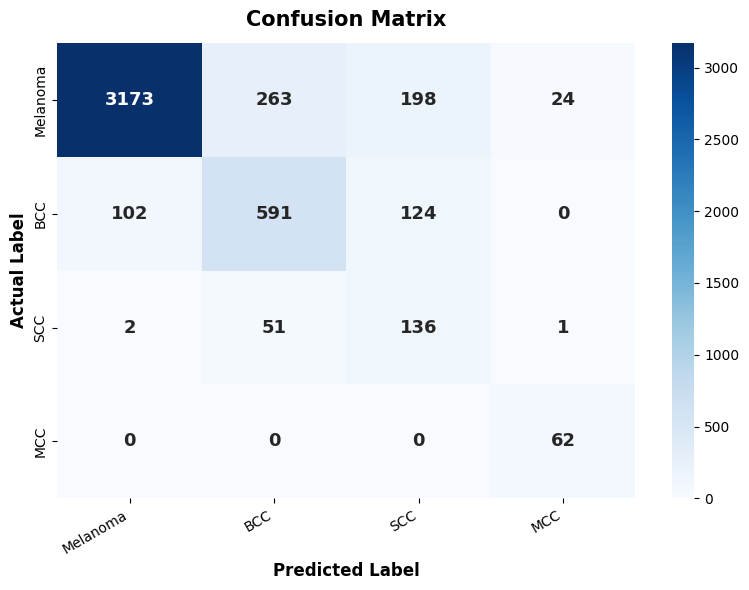

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

CLASS_NAMES = ["Melanoma", "BCC", "SCC", "MCC"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Resolve Data Loader & Model from memory
loader = None
for name in ["val_dl", "val_loader", "test_loader", "safe_test_loader"]:
    if name in globals():
        loader = globals()[name]
        break

if "model" not in globals():
    raise NameError("The variable 'model' is not loaded in memory. Please run the model definition/loading cell first.")

if loader is None:
    raise NameError("No data loader found (checked: val_dl, val_loader, test_loader). Run the data loader setup cell first.")

# 2. Extract predictions if 'all_labels' is not already in memory
if "all_labels" not in globals() or len(globals()["all_labels"]) == 0:
    print("Collecting predictions from evaluation loader...")
    
    # -> THE FIX: Move model to the correct device
    model = model.to(device)
    model.eval()
    
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for batch in loader:
            # Handle different dataset return formats:
            # Case A: (images, is_cancer, type_idx)
            if isinstance(batch, (list, tuple)):
                images = batch[0].to(device)
                labels = batch[-1].to(device) # type index is the last element
            # Case B: dict format {'image': ..., 'type_idx': ...}
            elif isinstance(batch, dict):
                images = batch["image"].to(device)
                labels = batch["type_idx"].to(device)
            else:
                continue

            # Forward pass
            out = model(images)
            logits = out["type"] if isinstance(out, dict) and "type" in out else (out["cancer"] if isinstance(out, dict) else out)
            if isinstance(logits, tuple):
                logits = logits[0]

            preds = torch.argmax(logits, dim=1)

            # Filter out non-cancer / negative type indices if present (-1)
            valid_mask = labels >= 0
            if valid_mask.any():
                all_labels.extend(labels[valid_mask].cpu().numpy().tolist())
                all_predictions.extend(preds[valid_mask].cpu().numpy().tolist())

# 3. Print Classification Report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(all_labels, all_predictions, target_names=CLASS_NAMES, digits=4, zero_division=0))

# 4. Generate & Display Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions, labels=list(range(len(CLASS_NAMES))))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={"size": 13, "weight": "bold"})
plt.title('Confusion Matrix', fontsize=15, fontweight='bold', pad=12)
plt.ylabel('Actual Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

1. LEARNING CURVES (LOSS & METRICS)
History dictionary not found in memory. Ensure metrics are appended to a 'history' dict during the training loop.

2. GRAD-CAM EXPLAINABILITY HEATMAP


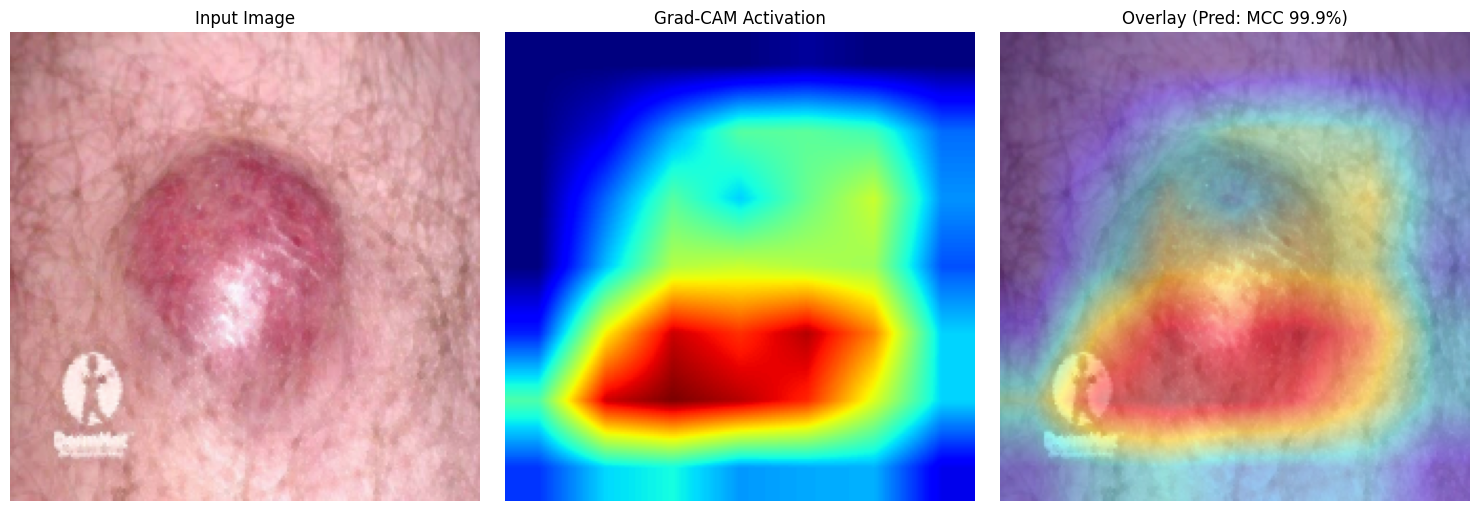


3. DIAGNOSTIC ASSESSMENT REPORT
DIAGNOSTIC TARGET: Lesion Sample
TRUE GROUND TRUTH: MCC
AI CLASSIFICATION: MCC
AI CONFIDENCE    : 99.89%
SYMPTOM COUNT    : 5/14 Positive Symptoms Detected
RISK CATEGORY    : Intermediate
------------------------------------------------------------
NOTE: Grad-CAM highlights the structural features (e.g., asymmetry, border
irregularity, or ulceration) that drove the classification decision.


In [10]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ["Melanoma", "BCC", "SCC", "MCC"]

# Ensure model is in eval mode and on the correct device
if "model" in globals():
    model = model.to(device)
    model.eval()
else:
    raise NameError("Model not found in memory.")

# ── 1. Learning Curves (Training vs Validation) ───────────────────────────
print("=" * 60)
print("1. LEARNING CURVES (LOSS & METRICS)")
print("=" * 60)

# Resolve history dictionary from memory
hist = None
for h_name in ['history', 'history_multimodal', 'history_df']:
    if h_name in globals():
        hist = globals()[h_name]
        # Convert DataFrame to dict if necessary
        if isinstance(hist, pd.DataFrame): 
            hist = hist.to_dict(orient='list')
        break

if hist is not None and "train_loss" in hist:
    epochs = range(1, len(hist['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss Curve
    ax1.plot(epochs, hist['train_loss'], 'b-', label='Training Loss', linewidth=2)
    if 'val_loss' in hist:
        ax1.plot(epochs, hist['val_loss'], 'r--', label='Validation Loss', linewidth=2)
    ax1.set_title('Model Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.6)
    
    # Accuracy / F1 Curve
    acc_key_tr = 'train_acc' if 'train_acc' in hist else ('train_f1' if 'train_f1' in hist else None)
    acc_key_va = 'val_acc' if 'val_acc' in hist else ('val_f1' if 'val_f1' in hist else None)
    
    if acc_key_tr:
        ax2.plot(epochs, hist[acc_key_tr], 'b-', label=f'Training {acc_key_tr.split("_")[1].upper()}', linewidth=2)
        if acc_key_va in hist:
            ax2.plot(epochs, hist[acc_key_va], 'r--', label=f'Validation {acc_key_va.split("_")[1].upper()}', linewidth=2)
        ax2.set_title('Model Performance Metric', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Epochs'); ax2.set_ylabel('Score')
        ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
else:
    print("History dictionary not found in memory. Ensure metrics are appended to a 'history' dict during the training loop.")


# ── 2. Grad-CAM Heatmap Generation ─────────────────────────────────────────
print("\n" + "=" * 60)
print("2. GRAD-CAM EXPLAINABILITY HEATMAP")
print("=" * 60)

def get_target_layer(m):
    """Dynamically find the last convolutional layer for Grad-CAM."""
    if hasattr(m, 'backbone'):
        if hasattr(m.backbone, 'conv_head'): return m.backbone.conv_head # EfficientNet
        if hasattr(m.backbone, 'layer4'): return m.backbone.layer4[-1].conv2 # ResNet
    elif hasattr(m, 'image_encoder'):
        if hasattr(m.image_encoder, 'layer4'): return m.image_encoder.layer4[-1].conv2
    
    # Fallback: scan backwards for the first Conv2d layer
    for module in reversed(list(m.modules())):
        if isinstance(module, torch.nn.Conv2d):
            return module
    return None

target_layer = get_target_layer(model)

if target_layer is None:
    print("Could not automatically identify the target convolutional layer for Grad-CAM.")
else:
    # Resolve dataloader to grab a sample
    loader = None
    for name in ["val_dl", "val_loader", "test_loader"]:
        if name in globals():
            loader = globals()[name]
            break

    if loader is not None:
        batch = next(iter(loader))
        
        # Extract image and labels based on batch format
        if isinstance(batch, dict):
            img_tensor = batch["image"][0:1].to(device)
            true_idx = batch["type_idx"][0].item()
            sym_tensor = batch["symptoms"][0:1].to(device) if "symptoms" in batch else None
        else:
            img_tensor = batch[0][0:1].to(device)
            true_idx = batch[-1][0].item()
            sym_tensor = batch[1][0:1].to(device) if len(batch) > 2 else None

        # Setup hooks
        acts, grads = {}, {}
        def fwd_hook(m, i, o): acts["v"] = o.detach()
        def bwd_hook(m, gi, go): grads["v"] = go[0].detach()
        
        h1 = target_layer.register_forward_hook(fwd_hook)
        h2 = target_layer.register_full_backward_hook(bwd_hook)
        
        # Forward pass requiring gradients
        model.zero_grad()
        img_tensor.requires_grad = True
        
        out = model(img_tensor, sym_tensor) if sym_tensor is not None else model(img_tensor)
        logits = out["type"] if isinstance(out, dict) and "type" in out else (out["cancer"] if isinstance(out, dict) else out)
        if isinstance(logits, tuple): logits = logits[0]
            
        pred_idx = logits.argmax(dim=1).item()
        confidence = torch.softmax(logits, dim=1)[0, pred_idx].item() * 100
        
        # Backward pass for the predicted class
        logits[0, pred_idx].backward()
        h1.remove(); h2.remove()
        
        # Calculate CAM
        wts = grads["v"].mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((wts * acts["v"]).sum(1))[0].cpu().detach().numpy()
        cam = cv2.resize(cam, (img_tensor.shape[2], img_tensor.shape[3]))
        if cam.max() != cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
            
        # Prepare original image for display (denormalize)
        img_disp = img_tensor[0].cpu().detach().numpy().transpose(1, 2, 0)
        mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
        img_disp = np.clip((img_disp * std + mean) * 255, 0, 255).astype(np.uint8)
        
        # Overlay heatmap
        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay = cv2.addWeighted(img_disp, 0.6, heatmap, 0.4, 0)
        
        # Plotting
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        ax[0].imshow(img_disp); ax[0].set_title("Input Image"); ax[0].axis("off")
        ax[1].imshow(cam, cmap="jet"); ax[1].set_title("Grad-CAM Activation"); ax[1].axis("off")
        ax[2].imshow(overlay); ax[2].set_title(f"Overlay (Pred: {CLASS_NAMES[pred_idx]} {confidence:.1f}%)"); ax[2].axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print("Data loader not found. Cannot grab sample for Grad-CAM.")


# ── 3. Visual Diagnostic Report ────────────────────────────────────────────
print("\n" + "=" * 60)
print("3. DIAGNOSTIC ASSESSMENT REPORT")
print("=" * 60)

if 'img_disp' in locals():
    # Print a structured text summary matching your EC05 requirements
    print(f"DIAGNOSTIC TARGET: Lesion Sample")
    print(f"TRUE GROUND TRUTH: {CLASS_NAMES[true_idx] if true_idx >= 0 else 'Unknown'}")
    print(f"AI CLASSIFICATION: {CLASS_NAMES[pred_idx]}")
    print(f"AI CONFIDENCE    : {confidence:.2f}%")
    
    # If symptom data exists, estimate proxy stage
    if sym_tensor is not None:
        sym_vals = sym_tensor[0].cpu().numpy()
        pos_count = int(sum(sym_vals))
        stage_risk = "Low" if pos_count <= 4 else ("Intermediate" if pos_count <= 8 else "High")
        print(f"SYMPTOM COUNT    : {pos_count}/14 Positive Symptoms Detected")
        print(f"RISK CATEGORY    : {stage_risk}")
        
    print("-" * 60)
    print("NOTE: Grad-CAM highlights the structural features (e.g., asymmetry, border")
    print("irregularity, or ulceration) that drove the classification decision.")
else:
    print("Please run the Grad-CAM block successfully to generate the diagnostic report.")